In [1]:
import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
BAD, GOOD, NEUTRAL, ACCENT = "#c0392b", "#1e8449", "#7f8c8d", "#2c6fbb"
RES = "../data/results/"


# 01 - Simulator validation

Everything downstream relies on the simulator, so it has to pass two tests first:
1. **A/A tests** (no real effect) must reject about 5% of the time with flat p-values.
2. **Known effects** must be recovered with about 95% CI coverage.

In [2]:
v = json.load(open(RES + "validation.json"))
print("A/A runs:", v["aa"]["runs"], "  false positive rate:", f'{v["aa"]["false_positive_rate"]:.3f}', "  KS test vs uniform p:", f'{v["aa"]["ks_uniform_p"]:.2f}')
pd.DataFrame(v["known_effect"])

A/A runs: 2000   false positive rate: 0.047   KS test vs uniform p: 0.08


,true_rel_lift,true_abs_effect,mean_estimate,ci_coverage
0,0.00,0.0000,-0.000090,0.954
1,0.05,0.0025,0.002396,0.947
2,0.10,0.0050,0.004885,0.953
3,0.20,0.0100,0.009900,0.951


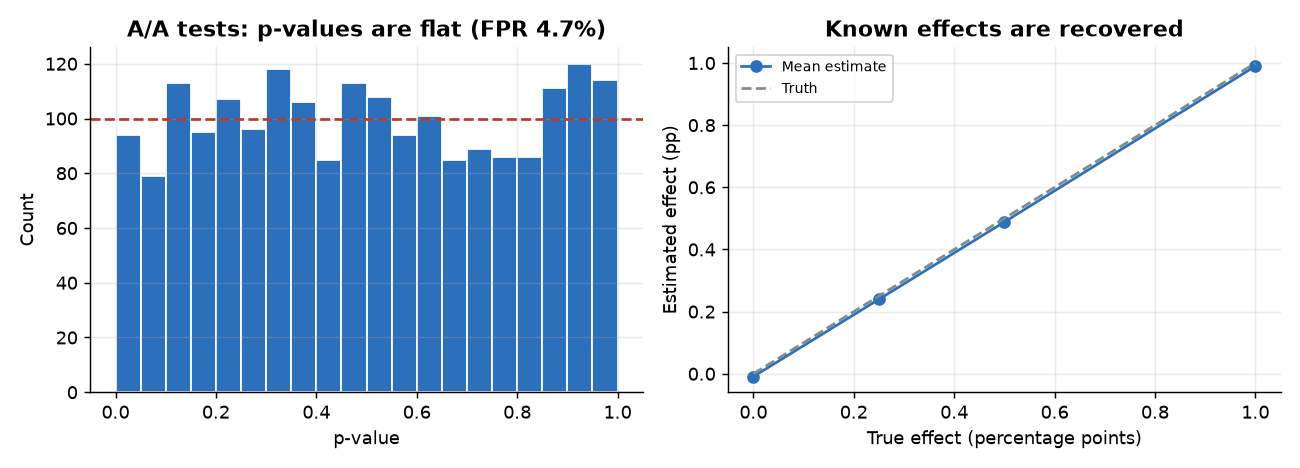

In [3]:
from IPython.display import Image
Image("../reports/figures/sim_validation.png")

**So what:** the simulator behaves like a fair experiment when nothing is going on, and recovers real effects when they exist. Any false positive measured later is therefore caused by the injected pitfall, not by the simulator.